<a href="https://colab.research.google.com/github/ranis8912/Purdue_AIML_Course/blob/CapstoneProject/Capstone_Project_Autonomous_Driving_SaiMandava.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!ls /content

Images.zip  sample_data


In [4]:
import shutil
shutil.unpack_archive("Images.zip")

In [5]:
import pandas as pd
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

Prepare the dataset for model training

In [7]:
#### Step 2: Load and preprocess the data

import os
import cv2
import numpy as np
import pandas as pd

# Load the labels from labels.csv
labels_df = pd.read_csv('labels.csv', sep=',', header=None)
labels_df.columns = ['image_id', 'class', 'x_min', 'y_min', 'x_max', 'y_max']

# Adjust the image IDs in the dataframe
labels_df['image_id'] = labels_df['image_id'].apply(lambda x: f"{x:08d}")

# Use iloc to pick the first 1000 labels
labels_df = labels_df.iloc[:1000]

# Load the corresponding images
images_dir = 'Images/'
images = []

TARGET_SIZE = (224, 224)   # <-- resize target

for index, row in labels_df.iterrows():
    img_path = os.path.join(images_dir, f"{row['image_id']}.jpg")
    img = cv2.imread(img_path)

    if img is None:
        print(f"Error loading image: {img_path}")
        continue

    # Resize to consistent shape
    img = cv2.resize(img, TARGET_SIZE)

    images.append(img)

# Convert list to NumPy array
images = np.array(images)

# Check if images are loaded
if len(images) == 0:
    print("No images loaded. Please check the image paths.")
else:
    print(f"{len(images)} images loaded successfully.")
    print("Image array shape:", images.shape)


1000 images loaded successfully.
Image array shape: (1000, 224, 224, 3)


In [8]:
# Analyze the distribution of vehicle types in the limited dataset
vehicle_types = labels_df['class'].value_counts()
print("Distribution of vehicle types:")
print(vehicle_types)

# Address data quality issues arising from the discrepancy between labels and actual image filenames
# Sorting the image filenames
labels_df = labels_df.sort_values('image_id')


Distribution of vehicle types:
class
car                      682
pickup_truck             111
motorized_vehicle         61
articulated_truck         30
work_van                  29
bus                       28
pedestrian                23
single_unit_truck         18
bicycle                   12
non-motorized_vehicle      5
motorcycle                 1
Name: count, dtype: int64


In [9]:
if len(images) > 0:
    processed_images = [cv2.resize(img, (224, 224)) for img in images]  # Adjust dimensions as needed
    processed_images = np.array(processed_images)
    print("Images resized successfully.")

Images resized successfully.


In [13]:
labels = labels_df['class'].to_numpy()
bounding_boxes = labels_df[['x_min', 'y_min', 'x_max', 'y_max']].to_numpy()

# Convert labels to one-hot encoding
unique_labels = np.unique(labels)
label_to_index = {label: index for index, label in enumerate(unique_labels)}
index_to_label = {index: label for index, label in enumerate(unique_labels)}
labels = np.array([label_to_index[label] for label in labels])
print(labels)

[ 8  3  3  0  3  2  2  3  3  3  3  5  3  3  2  3  0  3  3  8  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  8  3  3  3  3  3  3  3  3  3  8  3  3  3
  2  0 10  5  3  5  3  3  0  3  3  3  3  3  3  5  3  2  2  3  3  3  3  5
  8  3  8  3  3  8  3  9  9  3  3  3  3  8  3  3  3  3  3  3  3  3  3  3
  0  3  3  3  8  3  3  9  3  3  8  3  3  3  8  8  3  3  3  3  3  3  3  3
  3  8 10  3  3  3  3  3  3  5  2  3  3 10  3  3  3  3  3  3  3  3  3  3
  5  3  3  7  5  3  3  8  3  3  8  3  3  5  3  3  3  8  8 10  8  8  3  8
  3  3  3  5  3  5  5  8  3  8  8  3  3 10  0  5  3  8  3  5  3  3  3  3
  8  3  8  3  3  8  8  3  8 10  3  3  8  3  8  3  3  3  3  3  3  3  3  3
  5  0  1  3  3  3  3  3  3  3  3  3  3  3  8  3  3  3  3  3  3  3  3  3
  3  3  3  3 10  3 10  5  3  3  3  3  3  3 10  3  5  3  3  3  3  3  5  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  5  3  3  3  3  3  3  3  3
  3  2  3  3 10  3  3  3  3  3  3  3  3  0  2  3  0  3  3  3  3  8  3  3
  8  8  3  3  3  3  3  3  3  3  2  3  8  3  3  2  3

In [16]:
X_train, X_test, y_train, y_test, bbox_train, bbox_test = train_test_split(processed_images, labels, bounding_boxes, test_size=0.2, random_state=42)

Create an CNN architecture for object detection

In [17]:
def create_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    vehicle_class = layers.Dense(num_classes, activation='softmax', name='vehicle_class')(x)
    bounding_box = layers.Dense(4, name='bounding_box')(x)

    model = keras.Model(inputs=inputs, outputs=[vehicle_class, bounding_box])
    return model

input_shape = processed_images[0].shape
num_classes = len(unique_labels)
model = create_model(input_shape, num_classes)


model.compile(optimizer='adam',
              loss={'vehicle_class': 'sparse_categorical_crossentropy', 'bounding_box': 'mse'},
              metrics={'vehicle_class': 'accuracy', 'bounding_box': 'mae'})

model.fit(X_train, {'vehicle_class': y_train, 'bounding_box': bbox_train}, epochs=100, validation_data=(X_test, {'vehicle_class': y_test, 'bounding_box': bbox_test}))

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - bounding_box_loss: 851447.6875 - bounding_box_mae: 363.4235 - loss: 851903.1875 - vehicle_class_accuracy: 0.0350 - vehicle_class_loss: 455.8261 - val_bounding_box_loss: 30546.9160 - val_bounding_box_mae: 131.6678 - val_loss: 30025.7969 - val_vehicle_class_accuracy: 0.0150 - val_vehicle_class_loss: 87.1475
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - bounding_box_loss: 27004.8125 - bounding_box_mae: 128.5816 - loss: 27097.4258 - vehicle_class_accuracy: 0.3887 - vehicle_class_loss: 92.6145 - val_bounding_box_loss: 24228.0215 - val_bounding_box_mae: 123.4475 - val_loss: 24115.8945 - val_vehicle_class_accuracy: 0.6500 - val_vehicle_class_loss: 82.2737
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - bounding_box_loss: 25182.2871 - bounding_box_mae: 122.5142 - loss: 25256.7930 - vehicle_class_accuracy: 0.6200 - vehicle_class_loss: 74.5039 - val_bounding_box_loss: 22899.2188 - val_bounding_box_mae: 119.7360 - val_loss: 22715.36

Evaluate the model and check the test results

In [18]:
test_results = model.evaluate(X_test, {'vehicle_class': y_test, 'bounding_box': bbox_test}, verbose=2)
print('\nTest results:', test_results)

7/7 - 5s - 665ms/step - bounding_box_loss: 23224.3438 - bounding_box_mae: 112.9248 - loss: 22793.9922 - vehicle_class_accuracy: 0.6750 - vehicle_class_loss: 2.7382

Test results: [22793.9921875, 2.73823881149292, 23224.34375, 112.9248275756836, 0.675000011920929]


Run inferences on the images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step


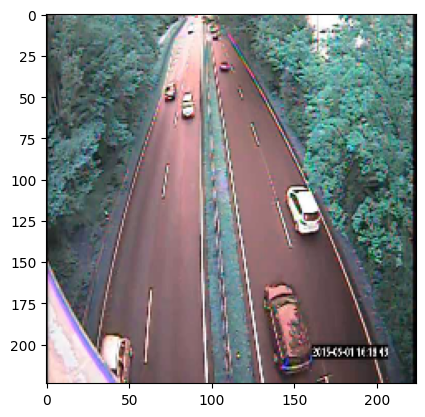

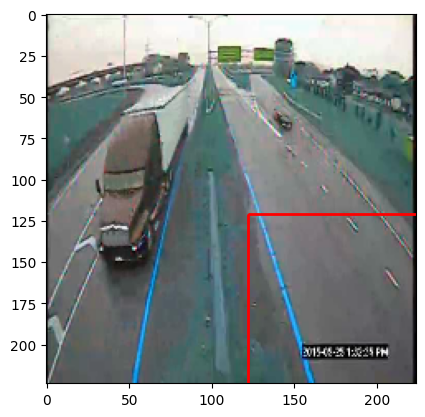

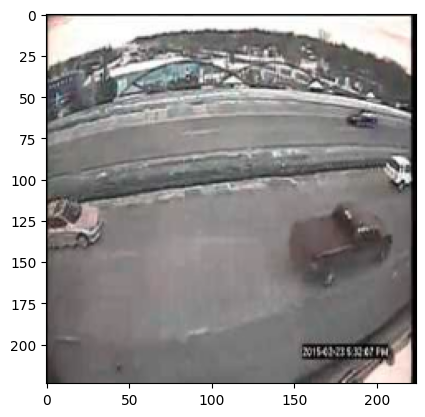

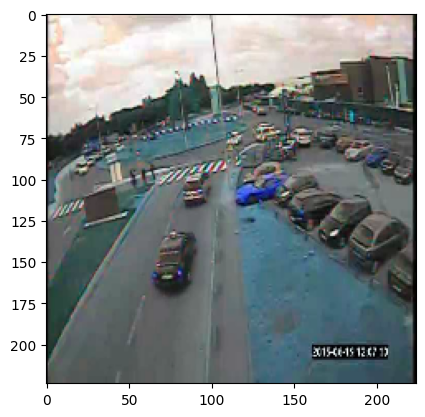

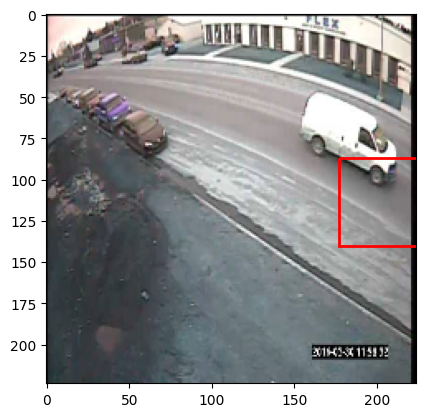

In [19]:
import matplotlib.pyplot as plt

# Choose a few sample images for inference
sample_images = X_test[:5]  # Adjust the number of sample images as needed

# Perform inference on the sample images
predictions = model.predict(sample_images)

# Extract the predicted bounding box coordinates
predicted_bounding_boxes = predictions[1]

# Visualize the sample images with predicted bounding boxes
for i in range(len(sample_images)):
    plt.figure()
    plt.imshow(sample_images[i])
    plt.gca().add_patch(plt.Rectangle((predicted_bounding_boxes[i][0], predicted_bounding_boxes[i][1]),
                                     predicted_bounding_boxes[i][2] - predicted_bounding_boxes[i][0],
                                     predicted_bounding_boxes[i][3] - predicted_bounding_boxes[i][1],
                                     fill=False, edgecolor='r', linewidth=2))
    plt.show()